<a href="https://colab.research.google.com/github/DeepanshuSharma1607/Fake_News_Generator_in_python/blob/main/ipl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [981]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [982]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "IPL_ball_by_ball_updated.csv"

df_23= kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "dgsports/ipl-ball-by-ball-2008-to-2022",
  file_path,
)
file_path = "deliveries_updated_ipl_upto_2025.csv"

df_ = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "dgsports/ipl-ball-by-ball-2008-to-2022",
  file_path,
)
file_path1 = "ipl_2024_deliveries.csv"
file_path2 = "ipl_2025_deliveries.csv"
file_path3 = "ipl_2026_deliveries.csv"
df_24= kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "sahiltailor/ipl-2024-ball-by-ball-dataset",
  file_path1,
)
df_25= kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "sahiltailor/ipl-2024-ball-by-ball-dataset",
  file_path2,
)
df_26= kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "sahiltailor/ipl-2024-ball-by-ball-dataset",
  file_path3,
)

Using Colab cache for faster access to the 'ipl-ball-by-ball-2008-to-2022' dataset.
Using Colab cache for faster access to the 'ipl-ball-by-ball-2008-to-2022' dataset.
Using Colab cache for faster access to the 'ipl-2024-ball-by-ball-dataset' dataset.
Using Colab cache for faster access to the 'ipl-2024-ball-by-ball-dataset' dataset.
Using Colab cache for faster access to the 'ipl-2024-ball-by-ball-dataset' dataset.


In [983]:
df_['season']=pd.to_datetime(df_['date']).dt.year

In [984]:
mapping = {
    'start_date':'date'
}
df_23.rename(columns=mapping, inplace=True)

mapping1= {
    "innings":"inning",
}
df_26.rename(columns=mapping1, inplace=True)
df_=df_.drop(columns=["over","ball"])

In [985]:
dv=[df_,df_23,df_24,df_25,df_26]
for df in dv:
  df['date']=pd.to_datetime(df['date'])

In [986]:
mapping = {
    'matchId':'match_id',
    'batsman':'striker',
    'isWide':'wide',
    'isNoBall':'noballs',
    "batsman_runs":"runs_of_bat",
    "dismissal_kind":"wicket_type",
    "LegByes":"legbyes",
    "Byes":"byes",
    "over_ball":"over"
}
df_.rename(columns=mapping, inplace=True)

In [987]:
team_mapping = {
    'Delhi Capitals': 'DC',
    'Delhi Daredevils': 'DC',

    'Punjab Kings': 'PBKS',
    'Kings XI Punjab': 'PBKS',

    'Royal Challengers Bangalore': 'RCB',
    'Royal Challengers Bengaluru': 'RCB',

    'Kolkata Knight Riders': 'KKR',
    'Chennai Super Kings': 'CSK',
    'Rajasthan Royals': 'RR',
    'Mumbai Indians': 'MI',
    'Sunrisers Hyderabad': 'SRH',
    'Lucknow Super Giants': 'LSG',
    'Gujarat Titans': 'GT',

    'Deccan Chargers': 'DC_OLD',
    'Kochi Tuskers Kerala': 'KTK',
    'Pune Warriors': 'PWI',
    'Rising Pune Supergiants': 'RPS',
    'Rising Pune Supergiant': 'RPS',
    'Gujarat Lions': 'GL',
}


df_['batting_team'] = df_['batting_team'].replace(team_mapping)
df_['bowling_team'] = df_['bowling_team'].replace(team_mapping)

df_23['batting_team'] = df_23['batting_team'].replace(team_mapping)
df_23['bowling_team'] = df_23['bowling_team'].replace(team_mapping)


In [988]:
venue_sources = [df_23, df_24, df_25, df_26]

venue_lookup = pd.concat([
    df[['date', 'batting_team', 'bowling_team', 'venue']]
    for df in venue_sources
]).drop_duplicates(subset=['date', 'batting_team', 'bowling_team'])

'''
1.We store all datasets in one list so we can process them together.
2.For each dataframe in the list, we select only these 4 columns and then combine (stack) all of them into one big dataframe.
3. pd.concat joins all selected dataframes into one single dataframe.
4. for df in venue_sources means we take each dataframe one by one from the list and apply column selection on it.
5.We remove duplicate matches by keeping only one row for each unique combination of date + batting team + bowling team.
'''

'\n1.We store all datasets in one list so we can process them together.\n2.For each dataframe in the list, we select only these 4 columns and then combine (stack) all of them into one big dataframe.\n3. pd.concat joins all selected dataframes into one single dataframe.\n4. for df in venue_sources means we take each dataframe one by one from the list and apply column selection on it.\n5.We remove duplicate matches by keeping only one row for each unique combination of date + batting team + bowling team.\n'

In [989]:
if 'venue' in df_.columns:
    df_ = df_.drop(columns=['venue'])

df_ = df_.merge(
    venue_lookup,
    on=['date', 'batting_team', 'bowling_team'],
    how='left'
)
'''
1. check in df_ if there is any column named venue if it is drop it
2. We join df_ with venue_lookup using date + batting_team + bowling_team as common keys
3.how='left' means: Keep all rows from df_ ,Add venue from venue_lookup wherever match is found

'''

"\n1. check in df_ if there is any column named venue if it is drop it\n2. We join df_ with venue_lookup using date + batting_team + bowling_team as common keys\n3.how='left' means: Keep all rows from df_ ,Add venue from venue_lookup wherever match is found\n\n"

In [990]:
df_.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278205 entries, 0 to 278204
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   match_id          278205 non-null  int64         
 1   inning            278205 non-null  int64         
 2   over              278205 non-null  float64       
 3   batting_team      278205 non-null  object        
 4   bowling_team      278205 non-null  object        
 5   striker           278205 non-null  object        
 6   non_striker       278205 non-null  object        
 7   bowler            278205 non-null  object        
 8   runs_of_bat       278205 non-null  int64         
 9   extras            278205 non-null  int64         
 10  wide              9080 non-null    float64       
 11  noballs           1163 non-null    float64       
 12  byes              701 non-null     float64       
 13  legbyes           4215 non-null    float64       
 14  Pena

In [991]:
df_26.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1382 entries, 0 to 1381
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   match_id          1382 non-null   int64         
 1   season            1382 non-null   int64         
 2   phase             1382 non-null   object        
 3   match_no          1382 non-null   int64         
 4   date              1382 non-null   datetime64[ns]
 5   venue             1382 non-null   object        
 6   batting_team      1382 non-null   object        
 7   bowling_team      1382 non-null   object        
 8   inning            1382 non-null   int64         
 9   over              1382 non-null   float64       
 10  striker           1382 non-null   object        
 11  bowler            1382 non-null   object        
 12  runs_of_bat       1382 non-null   int64         
 13  extras            1382 non-null   int64         
 14  wide              1382 n

In [992]:
df_.head(3)

,match_id,inning,over,batting_team,bowling_team,striker,non_striker,bowler,runs_of_bat,extras,wide,noballs,byes,legbyes,Penalty,wicket_type,player_dismissed,date,season,venue
0,335982,1,0.1,KKR,RCB,SC Ganguly,BB McCullum,P Kumar,0,1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,2008-04-18,2008,M Chinnaswamy Stadium
1,335982,1,0.2,KKR,RCB,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-18,2008,M Chinnaswamy Stadium
2,335982,1,0.3,KKR,RCB,BB McCullum,SC Ganguly,P Kumar,0,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-18,2008,M Chinnaswamy Stadium


In [993]:
df_26.head(3)

,match_id,season,phase,match_no,date,venue,batting_team,bowling_team,inning,over,...,bowler,runs_of_bat,extras,wide,legbyes,byes,noballs,wicket_type,player_dismissed,fielder
0,202601,2026,Group Stage,1,2026-03-28,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.1,...,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN
1,202601,2026,Group Stage,1,2026-03-28,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.2,...,Jacob Duffy,1,0,0,0,0,0,NaN,NaN,NaN
2,202601,2026,Group Stage,1,2026-03-28,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.3,...,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN


In [994]:
df_=df_.drop(columns=["date","Penalty","non_striker"])
df_26=df_26.drop(columns=["date",'match_no',"phase","fielder"])

In [995]:
print(df_.shape)
print(df_26.shape)

(278205, 17)
(1382, 17)


In [996]:
df_.columns

Index(['match_id', 'inning', 'over', 'batting_team', 'bowling_team', 'striker',
       'bowler', 'runs_of_bat', 'extras', 'wide', 'noballs', 'byes', 'legbyes',
       'wicket_type', 'player_dismissed', 'season', 'venue'],
      dtype='object')

In [997]:
df_['venue'] = (df_['venue']
             .str.split(',').str[0]
             .str.strip()
             .str.lower()
             .str.replace(' ', '_'))
df_26['venue'] = (df_26['venue']
             .str.split(',').str[0]
             .str.strip()
             .str.lower()
             .str.replace(' ', '_'))


In [998]:
df = pd.concat([df_, df_26])
print(df.shape)

(279587, 17)


In [999]:
df.head(10)

,match_id,inning,over,batting_team,bowling_team,striker,bowler,runs_of_bat,extras,wide,noballs,byes,legbyes,wicket_type,player_dismissed,season,venue
0,335982,1,0.1,KKR,RCB,SC Ganguly,P Kumar,0,1,NaN,NaN,NaN,1.0,NaN,NaN,2008,m_chinnaswamy_stadium
1,335982,1,0.2,KKR,RCB,BB McCullum,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2008,m_chinnaswamy_stadium
2,335982,1,0.3,KKR,RCB,BB McCullum,P Kumar,0,1,1.0,NaN,NaN,NaN,NaN,NaN,2008,m_chinnaswamy_stadium
3,335982,1,0.4,KKR,RCB,BB McCullum,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2008,m_chinnaswamy_stadium
4,335982,1,0.5,KKR,RCB,BB McCullum,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2008,m_chinnaswamy_stadium
5,335982,1,0.6,KKR,RCB,BB McCullum,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2008,m_chinnaswamy_stadium
6,335982,1,0.7,KKR,RCB,BB McCullum,P Kumar,0,1,NaN,NaN,NaN,1.0,NaN,NaN,2008,m_chinnaswamy_stadium
7,335982,1,1.1,KKR,RCB,BB McCullum,Z Khan,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2008,m_chinnaswamy_stadium
8,335982,1,1.2,KKR,RCB,BB McCullum,Z Khan,4,0,NaN,NaN,NaN,NaN,NaN,NaN,2008,m_chinnaswamy_stadium
9,335982,1,1.3,KKR,RCB,BB McCullum,Z Khan,4,0,NaN,NaN,NaN,NaN,NaN,NaN,2008,m_chinnaswamy_stadium


In [1000]:
df.isnull().sum()

,0
match_id,0
inning,0
over,0
batting_team,0
bowling_team,0
striker,0
bowler,0
runs_of_bat,0
extras,0
wide,269125


In [1001]:
print(df['bowling_team'].nunique())
print(df['batting_team'].nunique())

15
15


In [1002]:
df.columns

Index(['match_id', 'inning', 'over', 'batting_team', 'bowling_team', 'striker',
       'bowler', 'runs_of_bat', 'extras', 'wide', 'noballs', 'byes', 'legbyes',
       'wicket_type', 'player_dismissed', 'season', 'venue'],
      dtype='object')

In [1003]:
cols_to_fix = ['runs_of_bat', 'extras', 'wide', 'noballs', 'byes', 'legbyes']
df[cols_to_fix] = df[cols_to_fix].fillna(0)

df['curr_ball_runs'] = df['runs_of_bat'] + df['extras']
total_score = df.groupby(['match_id', 'inning', 'batting_team'])['curr_ball_runs'].cumsum().reset_index()


In [1004]:
df['team_runs'] = df.groupby(['match_id','batting_team'])['curr_ball_runs'].cumsum()
df['team_runs'] = df.groupby(['match_id','batting_team'])['team_runs'].shift(1).fillna(0)

In [1005]:
df['first_innings_runs'] = np.where(df['inning'] == 1, df['team_runs'], 0)
df['second_innings_runs'] = np.where(df['inning'] == 2, df['team_runs'], 0)

In [1006]:
df.head()

,match_id,inning,over,batting_team,bowling_team,striker,bowler,runs_of_bat,extras,wide,...,byes,legbyes,wicket_type,player_dismissed,season,venue,curr_ball_runs,team_runs,first_innings_runs,second_innings_runs
0,335982,1,0.1,KKR,RCB,SC Ganguly,P Kumar,0,1,0.0,...,0.0,1.0,NaN,NaN,2008,m_chinnaswamy_stadium,1,0.0,0.0,0.0
1,335982,1,0.2,KKR,RCB,BB McCullum,P Kumar,0,0,0.0,...,0.0,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,0,1.0,1.0,0.0
2,335982,1,0.3,KKR,RCB,BB McCullum,P Kumar,0,1,1.0,...,0.0,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,1,1.0,1.0,0.0
3,335982,1,0.4,KKR,RCB,BB McCullum,P Kumar,0,0,0.0,...,0.0,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,0,2.0,2.0,0.0
4,335982,1,0.5,KKR,RCB,BB McCullum,P Kumar,0,0,0.0,...,0.0,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,0,2.0,2.0,0.0


In [1007]:
df['is_wicket']=df['player_dismissed'].notna().astype(int)

In [1008]:
df.head()

,match_id,inning,over,batting_team,bowling_team,striker,bowler,runs_of_bat,extras,wide,...,legbyes,wicket_type,player_dismissed,season,venue,curr_ball_runs,team_runs,first_innings_runs,second_innings_runs,is_wicket
0,335982,1,0.1,KKR,RCB,SC Ganguly,P Kumar,0,1,0.0,...,1.0,NaN,NaN,2008,m_chinnaswamy_stadium,1,0.0,0.0,0.0,0
1,335982,1,0.2,KKR,RCB,BB McCullum,P Kumar,0,0,0.0,...,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,0,1.0,1.0,0.0,0
2,335982,1,0.3,KKR,RCB,BB McCullum,P Kumar,0,1,1.0,...,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,1,1.0,1.0,0.0,0
3,335982,1,0.4,KKR,RCB,BB McCullum,P Kumar,0,0,0.0,...,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,0,2.0,2.0,0.0,0
4,335982,1,0.5,KKR,RCB,BB McCullum,P Kumar,0,0,0.0,...,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,0,2.0,2.0,0.0,0


In [1009]:
totals = (df[df['inning'] == 1]
                 .groupby('match_id')['curr_ball_runs']
                 .sum()
                 .rename('target'))
df = df.merge(totals, on='match_id')
df['target'] = np.where(df['inning'] == 2, df['target'] + 1, 0)
'''
1. We create a dataframe (totals) where we select only first innings (inning = 1).
2. Then we group by match_id and sum all curr_ball_runs,
   which gives the total score of the first innings for each match.
3. We rename this total score column as 'target'.
4. Then we merge this target back into the main dataframe using match_id.
5. After merging, every row of that match now has the first innings total.
6. Finally, for second innings rows we set:
   target = first innings score + 1 (runs needed to win),
   and for first innings rows we set target = 0.
'''

"\n1. We create a dataframe (totals) where we select only first innings (inning = 1).\n2. Then we group by match_id and sum all curr_ball_runs,\n   which gives the total score of the first innings for each match.\n3. We rename this total score column as 'target'.\n4. Then we merge this target back into the main dataframe using match_id.\n5. After merging, every row of that match now has the first innings total.\n6. Finally, for second innings rows we set:\n   target = first innings score + 1 (runs needed to win),\n   and for first innings rows we set target = 0.\n"

In [1010]:
df['over_'] = df['over'].astype(str).str.split('.').str[0].astype(int)
df['ball_in_over'] = (df['over'].astype(str)
                      .str.split('.')
                      .str[1]
                      .fillna(0)
                      .astype(int))
'''
we have col over is like 0.1 0.1 0.3 ...12.3... so we take over_ as first part of 0.1... as 0
and ball_in_over as second part of 0.1... as 1
'''

'\nwe have col over is like 0.1 0.1 0.3 ...12.3... so we take over_ as first part of 0.1... as 0\nand ball_in_over as second part of 0.1... as 1\n'

In [1011]:
df['ball_in_over'] = df['ball_in_over'].clip(upper=6)
df['balls_bowled'] = df['over_'] * 6 + df['ball_in_over']
'''
1. it makes if balls >6 like become 7 then max it will make all >6 balls as 6
2. total balls calculated by over_ * 6 + ball_in_over
'''

'\n1. it makes if balls >6 like become 7 then max it will make all >6 balls as 6\n2. total balls calculated by over_ * 6 + ball_in_over\n'

In [1012]:
df['runs_to_win'] = np.where(
    df['inning'] == 2,
    df['target'] - df['team_runs'],
    0
)
'''
here created new col which tells live how many more runs needed to win the match
'''

'\nhere created new col which tells live how many more runs needed to win the match\n'

In [1013]:
balls_remaining = (120 - df['balls_bowled']).clip(lower=0)

In [1014]:
df['curr_run_rate'] = np.where(
    df['balls_bowled'] == 0, 0,
    (df['team_runs'] * 6) / df['balls_bowled']
)

In [1015]:
df['req_run_rate'] = np.where(
    balls_remaining == 0,
    np.inf,
    (df['runs_to_win'] * 6) / balls_remaining
)
df['req_run_rate'] = df['req_run_rate'].clip(0, 36)


In [1016]:
df['req_run_rate'] = df['req_run_rate'].replace(np.inf, 100)

In [1017]:
df['crr_rrr_ratio'] = df['curr_run_rate'] / df['req_run_rate'].replace(0, np.inf)

df['crr_rrr_ratio'] = df['crr_rrr_ratio'].clip(0, 10)

df.loc[df['inning'] == 1,
       ['target', 'runs_to_win', 'req_run_rate', 'crr_rrr_ratio']] = 0

In [1018]:
df['balls_remaining'] = (20 * 6) - df['balls_bowled'].clip(lower=0)

In [1019]:
df['total_wickets'] = df.groupby(['match_id','inning'])['is_wicket'].cumsum()
df['total_wickets'] = df.groupby(['match_id','inning'])['total_wickets'].shift(1).fillna(0)
df['wickets_remaining'] = 10 - df['total_wickets']

In [1020]:
df = df.sort_values(['match_id', 'inning', 'balls_bowled'])
df['recent_wickets'] = (
    df.groupby(['match_id', 'inning'])['is_wicket']
    .transform(lambda x: x.shift(1).rolling(18, min_periods=1).sum())
    .fillna(0)
)

df['recent_runs'] = (
    df.groupby(['match_id', 'inning'])['curr_ball_runs']
    .transform(lambda x: x.shift(1).rolling(18, min_periods=1).sum())
    .fillna(0)
)

'''
recent_wickets:
Number of wickets in last 18 balls BEFORE current ball

recent_runs:
Number of runs scored in last 18 balls BEFORE current ball
'''

'\nrecent_wickets:\nNumber of wickets in last 18 balls BEFORE current ball\n\nrecent_runs:\nNumber of runs scored in last 18 balls BEFORE current ball\n'

In [1021]:
df

,match_id,inning,over,batting_team,bowling_team,striker,bowler,runs_of_bat,extras,wide,...,balls_bowled,runs_to_win,curr_run_rate,req_run_rate,crr_rrr_ratio,balls_remaining,total_wickets,wickets_remaining,recent_wickets,recent_runs
278205,202601,1,0.1,SRH,RCB,Travis Head,Jacob Duffy,0,0,0.0,...,1,0.0,0.000000,0.0,0.000000,119,0.0,10.0,0.0,0.0
278206,202601,1,0.2,SRH,RCB,Travis Head,Jacob Duffy,1,0,0.0,...,2,0.0,0.000000,0.0,0.000000,118,0.0,10.0,0.0,0.0
278207,202601,1,0.3,SRH,RCB,Abhishek Sharma,Jacob Duffy,0,0,0.0,...,3,0.0,2.000000,0.0,0.000000,117,0.0,10.0,0.0,1.0
278208,202601,1,0.4,SRH,RCB,Abhishek Sharma,Jacob Duffy,6,0,0.0,...,4,0.0,1.500000,0.0,0.000000,116,0.0,10.0,0.0,1.0
278209,202601,1,0.5,SRH,RCB,Abhishek Sharma,Jacob Duffy,0,0,0.0,...,5,0.0,8.400000,0.0,0.000000,115,0.0,10.0,0.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276331,1485779,2,18.6,DC,PBKS,T Stubbs,Arshdeep Singh,4,0,0.0,...,114,12.0,10.263158,12.0,0.855263,6,4.0,6.0,0.0,37.0
276332,1485779,2,19.1,DC,PBKS,Sameer Rizvi,MP Stoinis,0,1,1.0,...,115,8.0,10.382609,9.6,1.081522,5,4.0,6.0,0.0,40.0
276333,1485779,2,19.2,DC,PBKS,Sameer Rizvi,MP Stoinis,1,0,0.0,...,116,7.0,10.344828,10.5,0.985222,4,4.0,6.0,0.0,39.0
276334,1485779,2,19.3,DC,PBKS,T Stubbs,MP Stoinis,1,0,0.0,...,117,6.0,10.307692,12.0,0.858974,3,4.0,6.0,0.0,39.0


In [1022]:
df['is_out'] = (df['player_dismissed'] == df['striker']).astype(int)

df['valid_ball'] = (df['wide'] == 0).astype(int)

season_bat = df.groupby(['season', 'striker']).agg(
    season_runs=('runs_of_bat', 'sum'),
    season_balls=('valid_ball', 'sum'),
    season_outs=('is_out', 'sum')
).reset_index().sort_values(['striker', 'season'])

season_bat = season_bat.sort_values(['striker', 'season']).reset_index(drop=True)

season_bat['career_runs'] = (season_bat.groupby('striker')['season_runs']
    .apply(lambda x: x.cumsum().shift(1)).droplevel(0).reindex(season_bat.index).fillna(0))

season_bat['career_balls'] = (season_bat.groupby('striker')['season_balls']
    .apply(lambda x: x.cumsum().shift(1)).droplevel(0).reindex(season_bat.index).fillna(0))

season_bat['career_outs'] = (season_bat.groupby('striker')['season_outs']
    .apply(lambda x: x.cumsum().shift(1)).droplevel(0).reindex(season_bat.index).fillna(0))

# Smoothed stats
season_bat['batting_average'] = (season_bat['career_runs'] + 50) / (season_bat['career_outs'] + 2)
season_bat['career_strike_rate'] = ((season_bat['career_runs'] + 100) / (season_bat['career_balls'] + 80)) * 100

# Merge back
df = df.merge(
    season_bat[['season', 'striker', 'batting_average', 'career_strike_rate']],
    on=['season', 'striker'], how='left'
)

In [1023]:
# Aggregate per bowler per season
season_bowl = df.groupby(['season', 'bowler']).agg(
    season_runs_c=('runs_of_bat', 'sum'),
    season_balls_b=('valid_ball', 'sum'),
    season_wkts=('is_wicket', 'sum')
).reset_index().sort_values(['bowler', 'season'])

season_bowl = season_bowl.sort_values(['bowler', 'season']).reset_index(drop=True)

season_bowl['career_runs_c'] = (season_bowl.groupby('bowler')['season_runs_c']
    .apply(lambda x: x.cumsum().shift(1)).droplevel(0).reindex(season_bowl.index).fillna(0))

season_bowl['career_balls_b'] = (season_bowl.groupby('bowler')['season_balls_b']
    .apply(lambda x: x.cumsum().shift(1)).droplevel(0).reindex(season_bowl.index).fillna(0))

season_bowl['career_wkts'] = (season_bowl.groupby('bowler')['season_wkts']
    .apply(lambda x: x.cumsum().shift(1)).droplevel(0).reindex(season_bowl.index).fillna(0))

# Smoothed stats
season_bowl['exp_bowler_eco'] = ((season_bowl['career_runs_c'] + 300) / (season_bowl['career_balls_b'] + 240)) * 6
season_bowl['exp_bowler_avg'] = (season_bowl['career_runs_c'] + 300) / (season_bowl['career_wkts'] + 10)

# Merge back
df = df.merge(
    season_bowl[['season', 'bowler', 'exp_bowler_eco', 'exp_bowler_avg']],
    on=['season', 'bowler'], how='left'
)

In [1024]:
df = df.sort_values(['season', 'match_id'])

In [1025]:
df.columns

Index(['match_id', 'inning', 'over', 'batting_team', 'bowling_team', 'striker',
       'bowler', 'runs_of_bat', 'extras', 'wide', 'noballs', 'byes', 'legbyes',
       'wicket_type', 'player_dismissed', 'season', 'venue', 'curr_ball_runs',
       'team_runs', 'first_innings_runs', 'second_innings_runs', 'is_wicket',
       'target', 'over_', 'ball_in_over', 'balls_bowled', 'runs_to_win',
       'curr_run_rate', 'req_run_rate', 'crr_rrr_ratio', 'balls_remaining',
       'total_wickets', 'wickets_remaining', 'recent_wickets', 'recent_runs',
       'is_out', 'valid_ball', 'batting_average', 'career_strike_rate',
       'exp_bowler_eco', 'exp_bowler_avg'],
      dtype='object')

In [1026]:
df.shape

(279587, 41)

In [1027]:
inning_totals = (df.groupby(['match_id','inning'])['curr_ball_runs']
                   .sum().reset_index()
                   .rename(columns={'curr_ball_runs':'inning_total'}))

scores_pivot = inning_totals.pivot(
    index='match_id', columns='inning', values='inning_total'
).reset_index()
scores_pivot.columns.name = None
scores_pivot.rename(columns={1:'inn1_total', 2:'inn2_total'}, inplace=True)

scores_pivot['winner_innings'] = np.where(
    scores_pivot['inn2_total'] > scores_pivot['inn1_total'], 2,
    np.where(scores_pivot['inn2_total'] < scores_pivot['inn1_total'], 1, 0)
)

df = df.merge(scores_pivot[['match_id','winner_innings']], on='match_id', how='left')

df['result'] = np.where(
    (df['inning']==2) & (df['winner_innings']==2), 1,
    np.where((df['inning']==2) & (df['winner_innings']==1), 0, -1)
)

print("Chasing win rate:", df[df['inning']==2]['result'].value_counts(normalize=True))


Chasing win rate: result
 1    0.506534
 0    0.478317
-1    0.015149
Name: proportion, dtype: float64


In [1028]:
match_results = (df[df['inning']==2]
    .drop_duplicates('match_id')[['match_id','batting_team','bowling_team','result']])

match_results['bat_won']  = (match_results['result'] == 1).astype(int)
match_results['bowl_won'] = (match_results['result'] == 0).astype(int)

match_results = match_results.sort_values('match_id')

match_results['batting_team_perf'] = (
    match_results.groupby('batting_team')['bat_won']
    .apply(lambda x: x.expanding().mean().shift(1))
    .reset_index(level=0, drop=True).fillna(0.5)
)
match_results['bowling_team_perf'] = (
    match_results.groupby('bowling_team')['bowl_won']
    .apply(lambda x: x.expanding().mean().shift(1))
    .reset_index(level=0, drop=True).fillna(0.5)
)

df = df.merge(
    match_results[['match_id','batting_team_perf','bowling_team_perf']],
    on='match_id', how='left'
)

In [1029]:
df['match_phase'] = pd.cut(df['over_'],
                            bins=[-1, 5, 14, 19],
                            labels=[0, 1, 2]).astype(int)

In [1030]:
df['first_innings_total'] = df['target'] - 1

In [1031]:
df.shape

(279587, 47)

In [1032]:
df.columns

Index(['match_id', 'inning', 'over', 'batting_team', 'bowling_team', 'striker',
       'bowler', 'runs_of_bat', 'extras', 'wide', 'noballs', 'byes', 'legbyes',
       'wicket_type', 'player_dismissed', 'season', 'venue', 'curr_ball_runs',
       'team_runs', 'first_innings_runs', 'second_innings_runs', 'is_wicket',
       'target', 'over_', 'ball_in_over', 'balls_bowled', 'runs_to_win',
       'curr_run_rate', 'req_run_rate', 'crr_rrr_ratio', 'balls_remaining',
       'total_wickets', 'wickets_remaining', 'recent_wickets', 'recent_runs',
       'is_out', 'valid_ball', 'batting_average', 'career_strike_rate',
       'exp_bowler_eco', 'exp_bowler_avg', 'winner_innings', 'result',
       'batting_team_perf', 'bowling_team_perf', 'match_phase',
       'first_innings_total'],
      dtype='object')

In [1033]:
drop_list = [
     'runs_of_bat', 'extras', 'wide','noballs', 'byes', 'legbyes',  'curr_ball_runs',
    'wicket_type', 'player_dismissed',  'is_wicket', 'is_out', 'winner_innings',
    'over', 'over_', 'ball_in_over', 'balls_bowled', 'valid_ball', 'team_runs',
    'first_innings_runs', 'second_innings_runs', 'target','total_wickets'
]
df = df.drop(columns=drop_list)

In [1034]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279587 entries, 0 to 279586
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   match_id             279587 non-null  int64  
 1   inning               279587 non-null  int64  
 2   batting_team         279587 non-null  object 
 3   bowling_team         279587 non-null  object 
 4   striker              279587 non-null  object 
 5   bowler               279587 non-null  object 
 6   season               279587 non-null  int64  
 7   venue                279587 non-null  object 
 8   runs_to_win          279587 non-null  float64
 9   curr_run_rate        279587 non-null  float64
 10  req_run_rate         279587 non-null  float64
 11  crr_rrr_ratio        279587 non-null  float64
 12  balls_remaining      279587 non-null  int64  
 13  wickets_remaining    279587 non-null  float64
 14  recent_wickets       279587 non-null  float64
 15  recent_runs      

In [1035]:
df['pressure'] = df['req_run_rate'] - df['curr_run_rate']

In [1036]:
df['inning'].unique()

array([1, 2, 3, 4, 5, 6])

In [1037]:
df = df[df['inning'] <= 2]
df = df[df['result'] != -1]

In [1038]:
df.describe()

,match_id,inning,season,runs_to_win,curr_run_rate,req_run_rate,crr_rrr_ratio,balls_remaining,wickets_remaining,recent_wickets,...,batting_average,career_strike_rate,exp_bowler_eco,exp_bowler_avg,result,batting_team_perf,bowling_team_perf,match_phase,first_innings_total,pressure
count,1.324940e+05,132494.0,132494.000000,132494.000000,132494.000000,132494.000000,132494.000000,132494.000000,132494.000000,132494.000000,...,132494.000000,132494.000000,132494.000000,132494.000000,132494.000000,132494.000000,132494.000000,132494.000000,132494.000000,132494.000000
mean,9.387651e+05,2.0,2016.731610,96.456851,7.379882,10.467482,0.942496,62.923015,7.559890,0.758155,...,28.408581,129.784580,7.515907,26.921471,0.514325,0.550805,0.457173,0.879859,169.397641,3.087600
std,3.838933e+05,0.0,5.272796,51.339717,2.374310,5.866723,0.958047,33.387179,2.139269,0.855714,...,7.718249,11.617523,0.480454,4.549176,0.499797,0.123168,0.128502,0.717949,31.740579,6.299360
min,2.026020e+05,2.0,2008.000000,-11.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,5.428571,83.544304,5.914198,14.846154,0.000000,0.000000,0.000000,0.000000,62.000000,-17.582609
25%,5.483480e+05,2.0,2012.000000,56.000000,6.210526,7.474576,0.536232,35.000000,6.000000,0.000000,...,24.647059,123.827392,7.301205,23.350000,0.000000,0.493976,0.418182,0.000000,149.000000,-0.459232
50%,1.082597e+06,2.0,2017.000000,95.000000,7.500000,9.252336,0.770227,64.000000,8.000000,1.000000,...,27.297297,127.073171,7.500000,27.058824,1.000000,0.548387,0.445946,1.000000,168.000000,2.166145
75%,1.304050e+06,2.0,2022.000000,134.000000,8.769231,11.526316,1.058742,92.000000,9.000000,1.000000,...,32.746154,135.689971,7.780718,30.000000,1.000000,0.593750,0.541667,1.000000,189.000000,5.255411
max,1.485779e+06,2.0,2026.000000,288.000000,24.000000,36.000000,10.000000,119.000000,10.000000,7.000000,...,67.333333,194.570136,9.079316,44.571429,1.000000,1.000000,0.833333,2.000000,287.000000,31.565217


In [1039]:
df = df[df['inning'] == 2]
df = df[df['runs_to_win'] >= 0]
df = df[df['balls_remaining'] > 0]

In [1040]:
df.describe()

,match_id,inning,season,runs_to_win,curr_run_rate,req_run_rate,crr_rrr_ratio,balls_remaining,wickets_remaining,recent_wickets,...,batting_average,career_strike_rate,exp_bowler_eco,exp_bowler_avg,result,batting_team_perf,bowling_team_perf,match_phase,first_innings_total,pressure
count,1.319020e+05,131902.0,131902.000000,131902.000000,131902.000000,131902.000000,131902.000000,131902.000000,131902.000000,131902.000000,...,131902.000000,131902.000000,131902.000000,131902.000000,131902.000000,131902.000000,131902.000000,131902.000000,131902.000000,131902.000000
mean,9.387436e+05,2.0,2016.731384,96.791739,7.376785,10.356981,0.945747,63.199838,7.580279,0.753863,...,28.436215,129.810204,7.515267,26.920101,0.516012,0.550778,0.457158,0.874945,169.347895,2.980196
std,3.838871e+05,0.0,5.272697,51.194589,2.377528,5.629962,0.958956,33.200660,2.119627,0.851846,...,7.708434,11.608810,0.480483,4.548565,0.499745,0.123156,0.128547,0.715716,31.737873,6.092913
min,2.026020e+05,2.0,2008.000000,1.000000,0.000000,0.077922,0.000000,1.000000,1.000000,0.000000,...,5.428571,83.544304,5.914198,14.846154,0.000000,0.000000,0.000000,0.000000,62.000000,-17.582609
25%,5.483482e+05,2.0,2012.000000,56.000000,6.204545,7.466667,0.539683,35.000000,6.000000,0.000000,...,24.685714,123.918175,7.301205,23.350000,0.000000,0.493976,0.418182,0.000000,149.000000,-0.473115
50%,1.082597e+06,2.0,2017.000000,95.000000,7.500000,9.236842,0.772220,64.000000,8.000000,1.000000,...,27.333333,127.095553,7.500000,27.058824,1.000000,0.548387,0.445946,1.000000,168.000000,2.142857
75%,1.304050e+06,2.0,2022.000000,135.000000,8.769231,11.482759,1.060606,92.000000,9.000000,1.000000,...,32.775510,135.693642,7.776000,30.000000,1.000000,0.593750,0.541667,1.000000,189.000000,5.203495
max,1.485779e+06,2.0,2026.000000,288.000000,24.000000,36.000000,10.000000,119.000000,10.000000,7.000000,...,67.333333,194.570136,9.079316,44.571429,1.000000,1.000000,0.833333,2.000000,287.000000,31.565217


In [1041]:
df['batting_team_perf'] = df['batting_team_perf'].fillna(0.5)
df['bowling_team_perf'] = df['bowling_team_perf'].fillna(0.5)
df = df.sort_values(['season'])

train_df = df[df['season'] <= 2023].copy()
test_df  = df[(df['season'] >= 2024) & (df['season'] <= 2026)].copy()

print(f"Train win%: {train_df['result'].mean():.3f} | Test win%: {test_df['result'].mean():.3f}")

Train win%: 0.520 | Test win%: 0.490


In [1042]:
train_df = train_df.drop(columns=['batting_team_perf', 'bowling_team_perf'])
test_df  = test_df.drop(columns=['batting_team_perf', 'bowling_team_perf'])

In [1043]:
nominal_cols     = ['batting_team', 'bowling_team']
categorical_cols = ['venue']
numeric_cols = [
    'runs_to_win', 'req_run_rate', 'balls_remaining',
    'wickets_remaining', 'match_phase', 'first_innings_total',
    'pressure', 'batting_team_perf', 'bowling_team_perf',
    'batting_average', 'career_strike_rate',
    'exp_bowler_eco', 'exp_bowler_avg',
    'recent_runs', 'recent_wickets',
]

In [1044]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, log_loss, brier_score_loss
)
from xgboost import XGBClassifier

def build_preprocessor():
    all_batting_teams_unique = sorted(train_df['batting_team'].unique())
    all_bowling_teams_unique = sorted(train_df['bowling_team'].unique())

    return ColumnTransformer(transformers=[
        ('nominal',     OneHotEncoder(sparse_output=False, drop='first',
                                      handle_unknown='ignore',
                                      categories=[all_batting_teams_unique, all_bowling_teams_unique]), nominal_cols),
        ('categorical', TargetEncoder(cv=5,smooth='auto'),categorical_cols),
        ('numeric',     StandardScaler(),numeric_cols),
    ])

neg = (train_df['result'] == 0).sum()
pos = (train_df['result'] == 1).sum()
scale = neg / pos

pipe = make_pipeline(
    build_preprocessor(),
    LogisticRegression(C=0.01, class_weight='balanced',
                       solver='liblinear', max_iter=1000)
)
xgb_pipe = make_pipeline(
    build_preprocessor(),
    XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.6,
    colsample_bytree=0.6,
    reg_lambda=10,
    reg_alpha=2,
    min_child_weight=30,
    gamma=2,
    scale_pos_weight=scale,
    early_stopping_rounds=30,
    eval_metric='auc',
    random_state=42,
    enable_categorical=True
)
)

In [1045]:
cv_scores_lr  = []
cv_scores_xgb = []
seasons=sorted(train_df['season'].unique())
for i in range(5, len(seasons)):

    train_seasons = seasons[:i]
    val_season    = seasons[i]

    tr_raw = train_df[train_df['season'].isin(train_seasons)].copy()
    vl_raw = train_df[train_df['season'] == val_season].copy()

    perf = make_team_perf(tr_raw)
    tr_raw = tr_raw.merge(perf, on='match_id', how='left')
    tr_raw[['batting_team_perf','bowling_team_perf']] = \
        tr_raw[['batting_team_perf','bowling_team_perf']].fillna(0.5)

    team_bat = (perf.merge(tr_raw[['match_id','batting_team']].drop_duplicates(), on='match_id')
                  .groupby('batting_team')['batting_team_perf'].last().to_dict())
    team_bowl = (perf.merge(tr_raw[['match_id','bowling_team']].drop_duplicates(), on='match_id')
                    .groupby('bowling_team')['bowling_team_perf'].last().to_dict())
    vl_raw['batting_team_perf'] = vl_raw['batting_team'].map(team_bat).fillna(0.5)
    vl_raw['bowling_team_perf'] = vl_raw['bowling_team'].map(team_bowl).fillna(0.5)

    X_tr  = tr_raw.drop(columns=['result', 'inning', 'season', 'striker', 'bowler','match_id'])
    y_tr  = tr_raw['result']
    X_val = vl_raw.drop(columns=['result', 'inning', 'season', 'striker', 'bowler','match_id'])
    y_val = vl_raw['result']

    pipe.fit(X_tr, y_tr)
    lr_acc = accuracy_score(y_val, pipe.predict(X_val))
    lr_auc = roc_auc_score(y_val, pipe.predict_proba(X_val)[:, 1])
    cv_scores_lr.append((lr_acc, lr_auc))

    preprocessor = xgb_pipe.named_steps['columntransformer']
    preprocessor.fit(X_tr, y_tr)
    X_tr_proc  = preprocessor.transform(X_tr)
    X_val_proc = preprocessor.transform(X_val)

    xgb_clf = xgb_pipe.named_steps['xgbclassifier']
    xgb_clf.fit(X_tr_proc, y_tr,
                eval_set=[(X_val_proc, y_val)],
                verbose=False)

    xgb_acc = accuracy_score(y_val, xgb_pipe.predict(X_val))
    xgb_auc = roc_auc_score(y_val, xgb_pipe.predict_proba(X_val)[:, 1])
    cv_scores_xgb.append((xgb_acc, xgb_auc))

    print(f"{train_seasons[-1]} → {val_season:<8} {lr_acc:>7.3f} {lr_auc:>7.3f}  {xgb_acc:>8.3f} {xgb_auc:>8.3f}")

2012 → 2013       0.827   0.907     0.818    0.889
2013 → 2014       0.777   0.869     0.761    0.863
2014 → 2015       0.753   0.840     0.766    0.835
2015 → 2016       0.760   0.829     0.748    0.841
2016 → 2017       0.708   0.826     0.706    0.821
2017 → 2018       0.689   0.784     0.683    0.777
2018 → 2019       0.731   0.832     0.763    0.873
2019 → 2020       0.817   0.895     0.795    0.883
2020 → 2021       0.782   0.855     0.777    0.867
2021 → 2022       0.780   0.871     0.773    0.868
2022 → 2023       0.745   0.837     0.769    0.835


In [1046]:
train_perf     = make_team_perf(train_df)
train_df_final = train_df.merge(train_perf, on='match_id', how='left')
train_df_final[['batting_team_perf','bowling_team_perf']] = \
    train_df_final[['batting_team_perf','bowling_team_perf']].fillna(0.5)

test_df_final = test_df.copy()

team_bat_perf = (
    train_perf
    .merge(train_df[['match_id','batting_team']].drop_duplicates(), on='match_id')
    .groupby('batting_team')['batting_team_perf'].last()
    .to_dict()
)
team_bowl_perf = (
    train_perf
    .merge(train_df[['match_id','bowling_team']].drop_duplicates(), on='match_id')
    .groupby('bowling_team')['bowling_team_perf'].last()
    .to_dict()
)

test_df_final['batting_team_perf'] = test_df_final['batting_team'].map(team_bat_perf).fillna(0.5)
test_df_final['bowling_team_perf'] = test_df_final['bowling_team'].map(team_bowl_perf).fillna(0.5)

x_train = train_df_final.drop(columns=['result','inning','season','striker','bowler','match_id'])
y_train = train_df_final['result']
x_test  = test_df_final.drop(columns=['result','inning','season','striker','bowler','match_id'])
y_test  = test_df_final['result']

print(f"Train: {len(x_train):,} rows | Test: {len(x_test):,} rows")

es_mask = train_df_final['season'] >= 2022
x_es = x_train[es_mask.values]
y_es = y_train[es_mask.values]

pipe.fit(x_train, y_train)
preprocessor = xgb_pipe.named_steps['columntransformer']
preprocessor.fit(x_train, y_train)
x_train_proc = preprocessor.transform(x_train)
x_es_proc    = preprocessor.transform(x_es)

xgb_clf = xgb_pipe.named_steps['xgbclassifier']
xgb_clf.fit(x_train_proc, y_train,
            eval_set=[(x_es_proc, y_es)],
            verbose=False)

print("Models fitted successfully")

print("Models fitted successfully")

Train: 115,266 rows | Test: 16,636 rows
Models fitted successfully
Models fitted successfully


In [1047]:
train_perf = make_team_perf(train_df)

team_bat_perf_dict = (
    train_perf
    .merge(train_df[['match_id','batting_team']].drop_duplicates(), on='match_id')
    .groupby('batting_team')['batting_team_perf']
    .last()
    .to_dict()
)

team_bowl_perf_dict = (
    train_perf
    .merge(train_df[['match_id','bowling_team']].drop_duplicates(), on='match_id')
    .groupby('bowling_team')['bowling_team_perf']
    .last()
    .to_dict()
)

batter_stats = (
    train_df
    .sort_values(['season'])
    .groupby('striker')
    .last()[['batting_average', 'career_strike_rate']]
    .to_dict(orient='index')
)

bowler_stats = (
    train_df
    .sort_values(['season'])
    .groupby('bowler')
    .last()[['exp_bowler_eco', 'exp_bowler_avg']]
    .to_dict(orient='index')
)

In [1048]:
lr_train_prob  = pipe.predict_proba(x_train)[:, 1]
lr_test_prob   = pipe.predict_proba(x_test)[:, 1]
lr_train_pred  = pipe.predict(x_train)
lr_test_pred   = pipe.predict(x_test)

xgb_train_prob = xgb_pipe.predict_proba(x_train)[:, 1]
xgb_test_prob  = xgb_pipe.predict_proba(x_test)[:, 1]
xgb_train_pred = xgb_pipe.predict(x_train)
xgb_test_pred  = xgb_pipe.predict(x_test)

ens_test_prob  = 0.65 * xgb_test_prob + 0.35 * lr_test_prob
ens_test_pred  = (ens_test_prob >= 0.5).astype(int)

In [1049]:
from catboost import CatBoostClassifier

cat_features = ['batting_team', 'bowling_team', 'venue']

x_train_cb = x_train.copy()
x_test_cb  = x_test.copy()

for col in cat_features:
    x_train_cb[col] = x_train_cb[col].astype(str)
    x_test_cb[col]  = x_test_cb[col].astype(str)

es_mask_cb = train_df_final['season'] >= 2022
x_es_cb = x_train_cb[es_mask_cb.values]
y_es_cb = y_train[es_mask_cb.values]

cat_model = CatBoostClassifier(
    iterations=200,
    depth=2,
    learning_rate=0.02,
    l2_leaf_reg=30,
    random_strength=10,
    bagging_temperature=2,
    border_count=64,
    cat_features=cat_features,
    eval_metric='AUC',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=False
)

cat_model.fit(
    x_train_cb, y_train,
    eval_set=(x_es_cb, y_es_cb)
)

print("CatBoost fitted successfully")

cat_train_prob = cat_model.predict_proba(x_train_cb)[:, 1]
cat_test_prob  = cat_model.predict_proba(x_test_cb)[:, 1]
cat_train_pred = cat_model.predict(x_train_cb)
cat_test_pred  = cat_model.predict(x_test_cb)

print("\n" + "="*58)
print(f"{'SUMMARY':^58}")
print("="*58)
print(f"{'Model':<24} {'Split':<7} {'Acc':>6} {'F1':>6} {'AUC':>7}")
print("-"*58)

for name, yt, yp, yprob, split in [
    ('Logistic Regression', y_train, lr_train_pred,  lr_train_prob,  'Train'),
    ('Logistic Regression', y_test,  lr_test_pred,   lr_test_prob,   'Test'),
    ('XGBoost',             y_train, xgb_train_pred, xgb_train_prob, 'Train'),
    ('XGBoost',             y_test,  xgb_test_pred,  xgb_test_prob,  'Test'),
    ('CatBoost',            y_train, cat_train_pred, cat_train_prob, 'Train'),
    ('CatBoost',            y_test,  cat_test_pred,  cat_test_prob,  'Test'),
]:
    print(f"{name:<24} {split:<7} "
          f"{accuracy_score(yt,yp):>6.4f} "
          f"{f1_score(yt,yp):>6.4f} "
          f"{roc_auc_score(yt,yprob):>7.4f}")
print("="*58)

CatBoost fitted successfully

                         SUMMARY                          
Model                    Split      Acc     F1     AUC
----------------------------------------------------------
Logistic Regression      Train   0.7972 0.8057  0.8863
Logistic Regression      Test    0.7672 0.7383  0.8619
XGBoost                  Train   0.8451 0.8510  0.9315
XGBoost                  Test    0.7699 0.7338  0.8673
CatBoost                 Train   0.8173 0.8249  0.9070
CatBoost                 Test    0.7826 0.7569  0.8705


In [1050]:
def print_metrics(name, y_true, y_pred, y_prob):
    print(f"\n{'='*45}\n  {name}\n{'='*45}")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1        : {f1_score(y_true, y_pred):.4f}")
    print(f"  ROC-AUC   : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"  Log Loss  : {log_loss(y_true, y_prob):.4f}")
    print(f"  Brier     : {brier_score_loss(y_true, y_prob):.4f}")
    print(classification_report(
        y_true, y_pred,
        target_names=['Bowling Wins', 'Batting Wins']
    ))

for header, rows in [
    ("LOGISTIC REGRESSION", [
        ("LR  — Train", y_train, lr_train_pred, lr_train_prob),
        ("LR  — Test",  y_test,  lr_test_pred,  lr_test_prob),
    ]),

    ("XGBOOST", [
        ("XGB — Train", y_train, xgb_train_pred, xgb_train_prob),
        ("XGB — Test",  y_test,  xgb_test_pred,  xgb_test_prob),
    ]),

    ("CATBOOST", [
        ("CB  — Train", y_train, cat_train_pred, cat_train_prob),
        ("CB  — Test",  y_test,  cat_test_pred,  cat_test_prob),
    ]),
]:
    print("\n" + "★"*45 + f"\n   {header}\n" + "★"*45)
    for row in rows:
        print_metrics(*row)


★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
   LOGISTIC REGRESSION
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★

  LR  — Train
  Accuracy  : 0.7972
  Precision : 0.8023
  Recall    : 0.8092
  F1        : 0.8057
  ROC-AUC   : 0.8863
  Log Loss  : 0.4206
  Brier     : 0.1371
              precision    recall  f1-score   support

Bowling Wins       0.79      0.78      0.79     55353
Batting Wins       0.80      0.81      0.81     59913

    accuracy                           0.80    115266
   macro avg       0.80      0.80      0.80    115266
weighted avg       0.80      0.80      0.80    115266


  LR  — Test
  Accuracy  : 0.7672
  Precision : 0.8215
  Recall    : 0.6704
  F1        : 0.7383
  ROC-AUC   : 0.8619
  Log Loss  : 0.4821
  Brier     : 0.1580
              precision    recall  f1-score   support

Bowling Wins       0.73      0.86      0.79      8486
Batting Wins       0.82      0.67      0.74      8150

    accuracy                           0.77     16636
   macro avg    

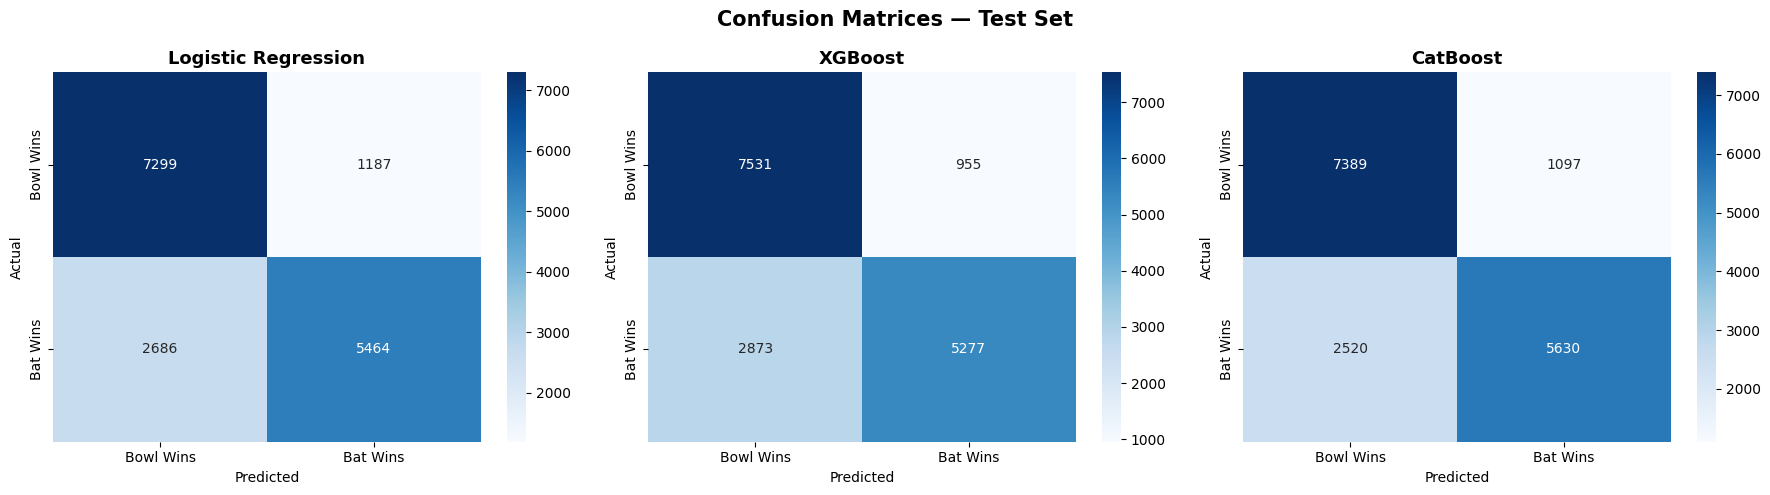

In [1051]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — Test Set', fontsize=15, fontweight='bold')

for ax, preds, title in zip(
    axes,
    [lr_test_pred, xgb_test_pred, cat_test_pred],
    ['Logistic Regression', 'XGBoost', 'CatBoost']
):
    sns.heatmap(confusion_matrix(y_test, preds),
                annot=True, fmt='d',
                cmap='Blues', ax=ax,
                xticklabels=['Bowl Wins', 'Bat Wins'],
                yticklabels=['Bowl Wins', 'Bat Wins'])

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

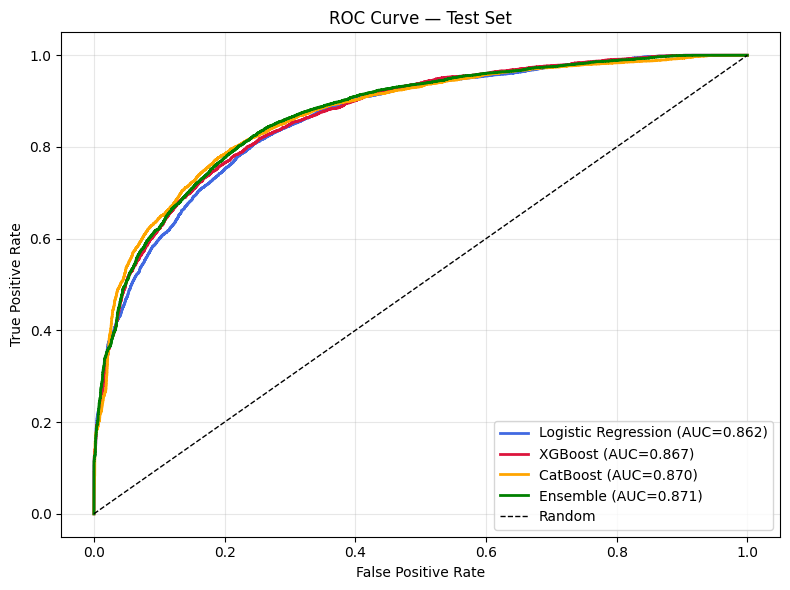

In [1052]:
fig, ax = plt.subplots(figsize=(8, 6))

for probs, name, color in [
    (lr_test_prob,  'Logistic Regression', 'royalblue'),
    (xgb_test_prob, 'XGBoost',             'crimson'),
    (cat_test_prob, 'CatBoost',            'orange'),
    (ens_test_prob, 'Ensemble',            'green'),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr,
            label=f'{name} (AUC={roc_auc_score(y_test, probs):.3f})',
            color=color, lw=2)

ax.plot([0,1],[0,1],'k--',lw=1,label='Random')
ax.set(xlabel='False Positive Rate',
       ylabel='True Positive Rate',
       title='ROC Curve — Test Set')

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

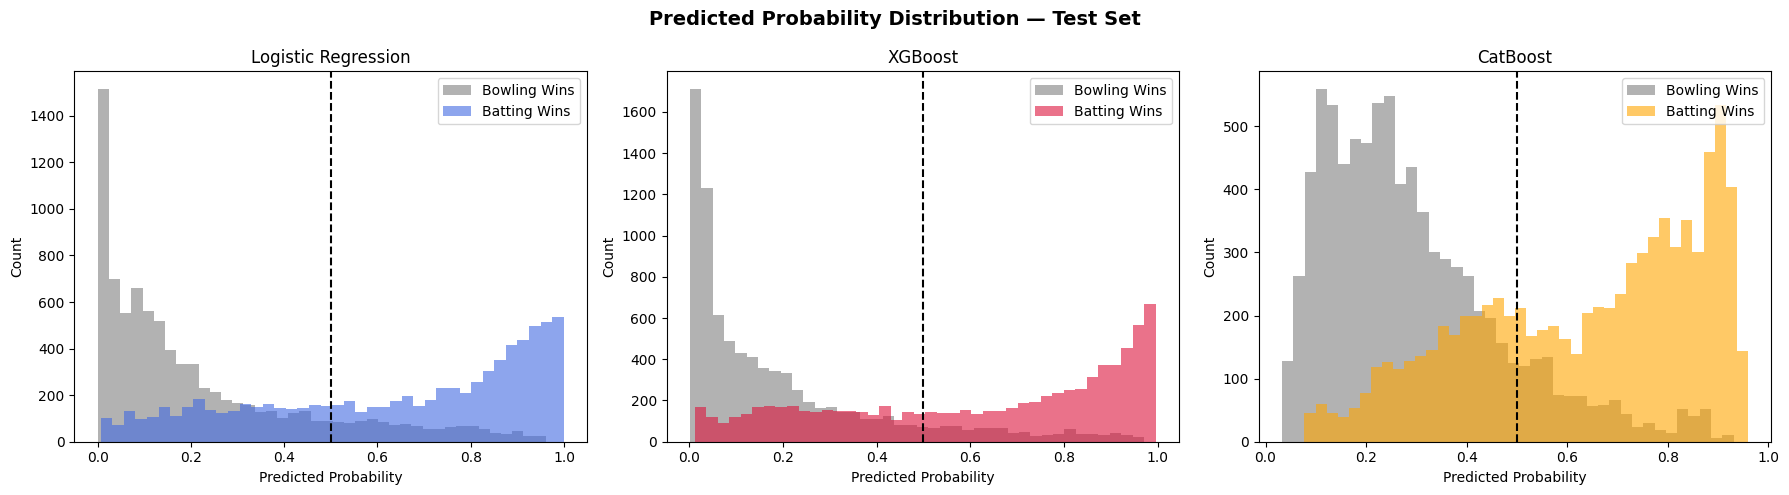

In [1053]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Predicted Probability Distribution — Test Set', fontsize=14, fontweight='bold')

for ax, probs, title, color in zip(
    axes,
    [lr_test_prob, xgb_test_prob, cat_test_prob],
    ['Logistic Regression', 'XGBoost', 'CatBoost'],
    ['royalblue', 'crimson', 'orange']
):
    ax.hist(probs[y_test==0], bins=40, alpha=0.6,
            label='Bowling Wins', color='gray')

    ax.hist(probs[y_test==1], bins=40, alpha=0.6,
            label='Batting Wins', color=color)

    ax.axvline(0.5, color='black', linestyle='--', lw=1.5)

    ax.set(title=title,
           xlabel='Predicted Probability',
           ylabel='Count')

    ax.legend()

plt.tight_layout()
plt.show()

In [1054]:
def predict_winner_all_models(
    batting_team, bowling_team, venue,
    runs_to_win, balls_remaining, wickets_remaining,
    team_runs_so_far, match_phase,
    first_innings_total,
    striker=None, bowler=None
):

    batting_team_perf = team_bat_perf_dict.get(batting_team, 0.5)
    bowling_team_perf = team_bowl_perf_dict.get(bowling_team, 0.5)

    if striker and striker in batter_stats:
        batting_average = batter_stats[striker]['batting_average']
        career_strike_rate = batter_stats[striker]['career_strike_rate']
    else:
        batting_average = 30
        career_strike_rate = 130

    if bowler and bowler in bowler_stats:
        exp_bowler_eco = bowler_stats[bowler]['exp_bowler_eco']
        exp_bowler_avg = bowler_stats[bowler]['exp_bowler_avg']
    else:
        exp_bowler_eco = 7.5
        exp_bowler_avg = 28

    balls_bowled = 120 - balls_remaining
    curr_run_rate = (team_runs_so_far * 6) / balls_bowled if balls_bowled > 0 else 0
    req_run_rate = (runs_to_win * 6) / balls_remaining
    pressure = req_run_rate - curr_run_rate

    crr_rrr_ratio = curr_run_rate / req_run_rate if req_run_rate != 0 else 100
    crr_rrr_ratio = np.clip(crr_rrr_ratio, 0, 10)

    recent_runs = 25
    recent_wickets = 1

    input_df = pd.DataFrame([{
        'batting_team': batting_team,
        'bowling_team': bowling_team,
        'venue': venue,
        'runs_to_win': runs_to_win,
        'curr_run_rate': curr_run_rate,
        'req_run_rate': req_run_rate,
        'crr_rrr_ratio': crr_rrr_ratio,
        'balls_remaining': balls_remaining,
        'wickets_remaining': wickets_remaining,
        'match_phase': match_phase,
        'first_innings_total': first_innings_total,
        'pressure': pressure,
        'batting_team_perf': batting_team_perf,
        'bowling_team_perf': bowling_team_perf,
        'batting_average': batting_average,
        'career_strike_rate': career_strike_rate,
        'exp_bowler_eco': exp_bowler_eco,
        'exp_bowler_avg': exp_bowler_avg,
        'recent_runs': recent_runs,
        'recent_wickets': recent_wickets
    }])

    input_df = input_df[x_train.columns]

    lr_prob  = pipe.predict_proba(input_df)[0]
    xgb_prob = xgb_pipe.predict_proba(input_df)[0]

    row_cb = input_df.copy()
    for col in ['batting_team', 'bowling_team', 'venue']:
        row_cb[col] = row_cb[col].astype(str)

    cat_prob = cat_model.predict_proba(row_cb)[0]

    ens_prob = 0.4 * xgb_prob + 0.4 * cat_prob + 0.2 * lr_prob

    print("\n" + "="*50)
    print("WIN PROBABILITY COMPARISON")
    print("="*50)

    def print_model(name, prob):
        winner = batting_team if prob[1] >= 0.5 else bowling_team
        print(f"\n{name}")
        print(f"{batting_team} win probability : {prob[1]:.2%}")
        print(f"{bowling_team} win probability : {prob[0]:.2%}")
        print(f"Predicted winner : {winner}")

    print_model("Logistic Regression", lr_prob)
    print_model("XGBoost", xgb_prob)
    print_model("CatBoost", cat_prob)
    print_model("Ensemble", ens_prob)

    return {
        "lr": lr_prob,
        "xgb": xgb_prob,
        "cat": cat_prob,
        "ensemble": ens_prob
    }

In [1055]:
predict_winner_all_models(
    'CSK', 'RCB', 'm_chinnaswamy_stadium',
    runs_to_win=91,
    balls_remaining=33,
    wickets_remaining=4,
    team_runs_so_far=160,
    match_phase=2,
    first_innings_total=251
)


WIN PROBABILITY COMPARISON

Logistic Regression
CSK win probability : 7.81%
RCB win probability : 92.19%
Predicted winner : RCB

XGBoost
CSK win probability : 2.13%
RCB win probability : 97.87%
Predicted winner : RCB

CatBoost
CSK win probability : 10.33%
RCB win probability : 89.67%
Predicted winner : RCB

Ensemble
CSK win probability : 6.55%
RCB win probability : 93.45%
Predicted winner : RCB


{'lr': array([0.92186281, 0.07813719]),
 'xgb': array([0.97867346, 0.02132653], dtype=float32),
 'cat': array([0.89673094, 0.10326906]),
 'ensemble': array([0.93453433, 0.06546567])}

In [1056]:
'''
predict_winner_all_models(
    'CSK', 'RCB', 'm_chinnaswamy_stadium',
    runs_to_win=146,
    balls_remaining=66,
    wickets_remaining=5,
    team_runs_so_far=105,
    match_phase=2,
    first_innings_total=251
)
==================================================
WIN PROBABILITY COMPARISON
==================================================

Logistic Regression
CSK win probability : 6.74%
RCB win probability : 93.26%
Predicted winner : RCB

XGBoost
CSK win probability : 2.88%
RCB win probability : 97.12%
Predicted winner : RCB

CatBoost
CSK win probability : 28.01%
RCB win probability : 71.99%
Predicted winner : RCB

Ensemble
CSK win probability : 13.70%
RCB win probability : 86.30%
Predicted winner : RCB
{'lr': array([0.93259955, 0.06740045]),
 'xgb': array([0.97124803, 0.02875195], dtype=float32),
 'cat': array([0.71986884, 0.28013116]),
 'ensemble': array([0.86296668, 0.13703333])}






predict_winner_all_models(
    'CSK', 'RCB', 'm_chinnaswamy_stadium',
    runs_to_win=94,
    balls_remaining=37,
    wickets_remaining=4,
    team_runs_so_far=157,
    match_phase=2,
    first_innings_total=251
)

==================================================
WIN PROBABILITY COMPARISON
==================================================

Logistic Regression
CSK win probability : 10.06%
RCB win probability : 89.94%
Predicted winner : RCB

XGBoost
CSK win probability : 1.90%
RCB win probability : 98.10%
Predicted winner : RCB

CatBoost
CSK win probability : 18.68%
RCB win probability : 81.32%
Predicted winner : RCB

Ensemble
CSK win probability : 10.25%
RCB win probability : 89.75%
Predicted winner : RCB
{'lr': array([0.89942162, 0.10057838]),
 'xgb': array([0.98095804, 0.01904193], dtype=float32),
 'cat': array([0.81318825, 0.18681175]),
 'ensemble': array([0.89754284, 0.10245715])}


predict_winner_all_models(
    'CSK', 'RCB', 'm_chinnaswamy_stadium',
    runs_to_win=91,
    balls_remaining=33,
    wickets_remaining=4,
    team_runs_so_far=160,
    match_phase=2,
    first_innings_total=251
)
==================================================
WIN PROBABILITY COMPARISON
==================================================

Logistic Regression
CSK win probability : 7.84%
RCB win probability : 92.16%
Predicted winner : RCB

XGBoost
CSK win probability : 1.84%
RCB win probability : 98.16%
Predicted winner : RCB

CatBoost
CSK win probability : 17.12%
RCB win probability : 82.88%
Predicted winner : RCB

Ensemble
CSK win probability : 9.15%
RCB win probability : 90.85%
Predicted winner : RCB
{'lr': array([0.92163619, 0.07836381]),
 'xgb': array([0.98156977, 0.01843021], dtype=float32),
 'cat': array([0.82876339, 0.17123661]),
 'ensemble': array([0.90846052, 0.09153949])}




'''

"\npredict_winner_all_models(\n    'CSK', 'RCB', 'm_chinnaswamy_stadium',\n    runs_to_win=146,\n    balls_remaining=66,\n    wickets_remaining=5,\n    team_runs_so_far=105,\n    match_phase=2,\n    first_innings_total=251\n)\n==================================================\nWIN PROBABILITY COMPARISON\n==================================================\n\nLogistic Regression\nCSK win probability : 6.74%\nRCB win probability : 93.26%\nPredicted winner : RCB\n\nXGBoost\nCSK win probability : 2.88%\nRCB win probability : 97.12%\nPredicted winner : RCB\n\nCatBoost\nCSK win probability : 28.01%\nRCB win probability : 71.99%\nPredicted winner : RCB\n\nEnsemble\nCSK win probability : 13.70%\nRCB win probability : 86.30%\nPredicted winner : RCB\n{'lr': array([0.93259955, 0.06740045]),\n 'xgb': array([0.97124803, 0.02875195], dtype=float32),\n 'cat': array([0.71986884, 0.28013116]),\n 'ensemble': array([0.86296668, 0.13703333])}\n\n\n\n\n\n\npredict_winner_all_models(\n    'CSK', 'RCB', 'm_c